# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [3]:
medical.shape

(1338, 8)

In [4]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__ The histogram displays a heavily right-skewed distribution. This makes sense in the context of medical charges, where the majority are below the mean of roughly \$13k, but a large number of them float upwards of \$60k. This type of distribution does not lend itself to being well represented with summary statistics such as the mean and standard deviation, since they're more sensitive to extreme values. The sample's median or IQR may be better choices for representing the typical medical charge.

In [46]:
charges_mean = medical['charges'].mean()
charges_std = medical['charges'].std(ddof=1)
print(f"Mean: {charges_mean}, Standard Deviation: {charges_std}")

Mean: 13270.422265141257, Standard Deviation: 12110.011236694001


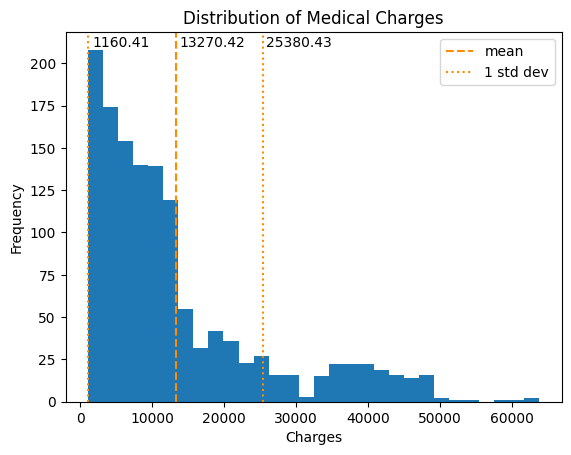

In [40]:
_ = plt.hist(medical['charges'], bins=30)
_ = plt.xlabel('Charges')
_ = plt.ylabel('Frequency')
_ = plt.title('Distribution of Medical Charges')
_ = plt.axvline(charges_mean, color='darkorange', linestyle='dashed', label='mean')
_ = plt.axvline(charges_mean + charges_std, color='darkorange', linestyle='dotted', label='1 std dev')
_ = plt.axvline(charges_mean - charges_std, color='darkorange', linestyle='dotted')
_ = plt.legend()
_ = plt.text(charges_mean + 500, 210, f'{charges_mean:.2f}')
_ = plt.text(charges_mean + charges_std + 500, 210, f'{charges_mean + charges_std:.2f}')
_ = plt.text(charges_mean - charges_std + 500, 210, f'{charges_mean - charges_std:.2f}')
plt.show()

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ Given that the data is a random sample and reasonably large, CLT suggests that the sampling distribution of sample means should be approximately normal. This allows us to make inferences about the population mean in combination with our sample mean and standard error.

Since the population standard deviation is unknown, the most appropriate frequentist test we could use is a one sample t-test. 

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ Since the administrator is purely concerned with the population mean being below 12,000, a one-sided 95% confidence interval is appropriate for testing this hypothesis. Calculating the lower bound using our sample standard deviation, standard error, and t-critical value, we end up with a confidence interval of roughly $(12725.49, \infty)$ placing us well above the range for a population mean of 12,000 or less. Thus, the conclusion is that the administrator should not be concerned.

In [47]:
n = len(medical['charges'])
standard_error = charges_std / np.sqrt(n)
print(f"Standard Error: {standard_error}")

Standard Error: 331.0674543156824


In [58]:
t_crit = t.ppf(0.95, df=n-1)
margin_of_error = t_crit * standard_error
print(f"T-critical Value: {t_crit}, Margin of Error: {margin_of_error}")

T-critical Value: 1.6459941145571315, Margin of Error: 544.9350813250253


In [59]:
lower_bound = charges_mean - margin_of_error
print(f"95% Confidence Interval: ({lower_bound}, inf)")

95% Confidence Interval: (12725.48718381623, inf)


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__

If we let:
- $\mu_{0} = $ mean charge for patients **without** insurance
- $\mu_{1} = $ mean charge for patients **with** insurance

Then our hypotheses are:
- $H_{0}: \mu_{0} = \mu_{1}$
- $H_{A}: \mu_{0} \ne \mu_{1}$

The assumption we're making with the pooled standard deviation is that both groups have equal population variance.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [62]:
non_insured_patients = medical[medical['insuranceclaim'] == 0]['charges']
insured_patients = medical[medical['insuranceclaim'] == 1]['charges']

n0 = len(non_insured_patients)
n1 = len(insured_patients)
mean0 = non_insured_patients.mean()
mean1 = insured_patients.mean()
std0 = non_insured_patients.std(ddof=1)
std1 = insured_patients.std(ddof=1)

print(f"Non-insured patients: n0 = {n0}, x̄0 = {mean0}, s0 = {std0}")
print(f"Insured patients: n1 = {n1}, x̄1 = {mean1}, s1 = {std1}")

Non-insured patients: n0 = 555, x̄0 = 8821.421892306305, s0 = 6446.510126811738
Insured patients: n1 = 783, x̄1 = 16423.928276537677, s1 = 14045.928418802134


In [64]:
dof = n0 + n1 - 2
sp = np.sqrt(((n0 - 1) * std0**2 + (n1 - 1) * std1**2) / (dof))
print(f"Pooled Standard Deviation: {sp}")
t_stat = (mean0 - mean1) / (sp * np.sqrt(1/n0 + 1/n1))
print(f"T-statistic: {t_stat}")
p_value = t.sf(np.abs(t_stat), df=dof) * 2
print(f"P-value: {p_value}")

Pooled Standard Deviation: 11520.034268775262
T-statistic: -11.89329903087671
P-value: 4.461230231620825e-31


In [70]:
# Since we only imported t from scipy.stats, we need to import ttest_ind separately to use it for the "non-manual" t-test.
from scipy.stats import ttest_ind

t_stat_scipy, p_value_scipy = ttest_ind(non_insured_patients, insured_patients, equal_var=True)
print(f"T-statistic: {t_stat_scipy}, P-value: {p_value_scipy}")

T-statistic: -11.893299030876712, P-value: 4.461230231620826e-31


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ I had a hard time finding any direct function provided by the `scipy.stats` library which serves as a z-test similar to `ttest_ind`. There are the various distribution methods under `scipy.stat.norm` like cdf or ppf which provide the base to build z-tests, but none that are quite as all encompassing as the test wrappers provided for t-tests.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test